In [1]:
import pandas as pd
import numpy as np
import os
import glob

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
import pandas as pd

# Main NHANES files
demo = pd.read_sas("masld_data/DEMO_L.xpt")
bmx = pd.read_sas("masld_data/BMX_L.xpt")
bpx = pd.read_sas("masld_data/BPXO_L.xpt")
lux = pd.read_sas("masld_data/LUX_L.xpt")

# Laboratory files
glu = pd.read_sas("masld_data/Laboratory/GLU_L.xpt")
hdl = pd.read_sas("masld_data/Laboratory/HDL_L.xpt")
tchol = pd.read_sas("masld_data/Laboratory/TCHOL_L.xpt")
trigly = pd.read_sas("masld_data/Laboratory/TRIGLY_L.xpt")

# Questionnaire files
alq = pd.read_sas("masld_data/Questionnaire/ALQ_L.xpt")
paq = pd.read_sas("masld_data/Questionnaire/PAQ_L.xpt")

print("All files loaded successfully!")

All files loaded successfully!


In [4]:
datasets = {
    "DEMO": demo,
    "BMX": bmx,
    "BPXO": bpx,
    "LUX": lux,
    "GLU": glu,
    "HDL": hdl,
    "TCHOL": tchol,
    "TRIGLY": trigly,
    "ALQ": alq,
    "PAQ": paq
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

DEMO: (11933, 27)
BMX: (8860, 22)
BPXO: (7801, 12)
LUX: (7199, 13)
GLU: (3996, 4)
HDL: (8068, 4)
TCHOL: (8068, 4)
TRIGLY: (3996, 10)
ALQ: (6337, 9)
PAQ: (8153, 8)


In [5]:
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(df.columns.tolist())


DEMO
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR']

BMX
['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']

BPXO
['SEQN', 'BPAOARM', 'BPAOCSZ', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3']

LUX
['SEQN', 'LUAXSTAT', 'LUARXNC', 'LUARXND', 'LUARXIN', 'LUAPNME', 'LUANMVGP', 'LUANMTGP', 'LUXSMED', 'LUXSIQR', 'LUXSIQRM', 'LUXCAPM', 'LUXCPIQR']

GLU
['SEQN', 'WTSAF2YR', 'LBXGLU', 'LBDGLUSI']

HDL
['SEQN', 'WTPH2YR', 'LBDHDD', 'LBDHDDSI']

TCHOL
['SEQN', 'WTPH2YR', 'LBXTC', 'LBDTCSI']

TRIG

In [6]:
print("HDL:")
print(hdl.columns.tolist())

print("\nTOTAL CHOLESTEROL:")
print(tchol.columns.tolist())

print("\nTRIGLYCERIDES:")
print(trigly.columns.tolist())

print("\nALCOHOL:")
print(alq.columns.tolist())

print("\nPHYSICAL ACTIVITY:")
print(paq.columns.tolist())

HDL:
['SEQN', 'WTPH2YR', 'LBDHDD', 'LBDHDDSI']

TOTAL CHOLESTEROL:
['SEQN', 'WTPH2YR', 'LBXTC', 'LBDTCSI']

TRIGLYCERIDES:
['SEQN', 'WTSAF2YR', 'LBXTLG', 'LBDTRSI', 'LBDLDL', 'LBDLDLSI', 'LBDLDLM', 'LBDLDMSI', 'LBDLDLN', 'LBDLDNSI']

ALCOHOL:
['SEQN', 'ALQ111', 'ALQ121', 'ALQ130', 'ALQ142', 'ALQ270', 'ALQ280', 'ALQ151', 'ALQ170']

PHYSICAL ACTIVITY:
['SEQN', 'PAD790Q', 'PAD790U', 'PAD800', 'PAD810Q', 'PAD810U', 'PAD820', 'PAD680']


In [7]:
# Select the variables we need from each NHANES dataset

demo_sel = demo[
    ["SEQN", "RIDAGEYR", "RIAGENDR"]
].copy()

bmx_sel = bmx[
    ["SEQN", "BMXBMI", "BMXWAIST"]
].copy()

bpx_sel = bpx[
    ["SEQN", "BPXOSY1", "BPXOSY2", "BPXOSY3",
     "BPXODI1", "BPXODI2", "BPXODI3"]
].copy()

lux_sel = lux[
    ["SEQN", "LUXCAPM"]
].copy()

glu_sel = glu[
    ["SEQN", "LBXGLU"]
].copy()

hdl_sel = hdl[
    ["SEQN", "LBDHDD"]
].copy()

tchol_sel = tchol[
    ["SEQN", "LBXTC"]
].copy()

trigly_sel = trigly[
    ["SEQN", "LBXTLG"]
].copy()

alq_sel = alq[
    ["SEQN", "ALQ111", "ALQ121", "ALQ130", "ALQ142",
     "ALQ270", "ALQ280", "ALQ151", "ALQ170"]
].copy()

paq_sel = paq[
    ["SEQN", "PAD790Q", "PAD790U", "PAD800",
     "PAD810Q", "PAD810U", "PAD820", "PAD680"]
].copy()

print("Variables selected successfully.")

Variables selected successfully.


In [8]:
# Start with LUX because it provides our liver measurement
df = lux_sel.copy()

# Merge the remaining datasets using SEQN
df = df.merge(demo_sel, on="SEQN", how="left")
df = df.merge(bmx_sel, on="SEQN", how="left")
df = df.merge(bpx_sel, on="SEQN", how="left")
df = df.merge(glu_sel, on="SEQN", how="left")
df = df.merge(hdl_sel, on="SEQN", how="left")
df = df.merge(tchol_sel, on="SEQN", how="left")
df = df.merge(trigly_sel, on="SEQN", how="left")
df = df.merge(alq_sel, on="SEQN", how="left")
df = df.merge(paq_sel, on="SEQN", how="left")

print("Merged dataset shape:", df.shape)
print(df.head())

Merged dataset shape: (7199, 31)
       SEQN  LUXCAPM  RIDAGEYR  RIAGENDR  BMXBMI  BMXWAIST  BPXOSY1  BPXOSY2  \
0  130378.0    380.0      43.0       1.0    27.0      98.3    135.0    131.0   
1  130379.0    345.0      66.0       1.0    33.5     114.7    121.0    117.0   
2  130380.0    255.0      44.0       2.0    29.7      93.5    111.0    112.0   
3  130386.0    163.0      34.0       1.0    30.2     106.1    110.0    120.0   
4  130387.0      NaN      68.0       2.0    42.6     122.0    143.0    136.0   

   BPXOSY3  BPXODI1  BPXODI2  BPXODI3  LBXGLU  LBDHDD  LBXTC  LBXTLG  ALQ111  \
0    132.0     98.0     96.0     94.0   113.0    45.0  264.0   153.0     NaN   
1    113.0     84.0     76.0     76.0    99.0    60.0  214.0    86.0     1.0   
2    104.0     79.0     80.0     76.0   156.0    49.0  187.0   375.0     1.0   
3    115.0     72.0     74.0     75.0   100.0    46.0  183.0   142.0     1.0   
4    145.0     76.0     74.0     78.0     NaN    42.0  203.0     NaN     1.0   

     

In [9]:
missing = df.isnull().sum()

missing_percentage = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage
})

print(missing_summary)

          Missing_Count  Missing_Percentage
SEQN                  0                0.00
LUXCAPM             500                6.95
RIDAGEYR              0                0.00
RIAGENDR              0                0.00
BMXBMI              107                1.49
BMXWAIST            354                4.92
BPXOSY1             252                3.50
BPXOSY2             259                3.60
BPXOSY3             276                3.83
BPXODI1             252                3.50
BPXODI2             259                3.60
BPXODI3             276                3.83
LBXGLU             3527               48.99
LBDHDD              808               11.22
LBXTC               808               11.22
LBXTLG             3682               51.15
ALQ111             1718               23.86
ALQ121             2277               31.63
ALQ130             3130               43.48
ALQ142             3117               43.30
ALQ270             4833               67.13
ALQ280             4837         

In [10]:
# Average the available blood pressure measurements

df["Systolic_BP"] = df[
    ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
].mean(axis=1)

df["Diastolic_BP"] = df[
    ["BPXODI1", "BPXODI2", "BPXODI3"]
].mean(axis=1)

# Check the result
df[["Systolic_BP", "Diastolic_BP"]].head()

,Systolic_BP,Diastolic_BP
0,132.666667,96.000000
1,117.000000,78.666667
2,109.000000,78.333333
3,115.000000,73.666667
4,141.333333,76.000000


In [11]:
df = df.rename(columns={
    "RIDAGEYR": "Age",
    "RIAGENDR": "Sex",
    "BMXBMI": "BMI",
    "BMXWAIST": "Waist",
    "LUXCAPM": "CAP",
    "LBXGLU": "Glucose",
    "LBDHDD": "HDL",
    "LBXTC": "Total_Cholesterol",
    "LBXTLG": "Triglycerides"
})

print(df.columns.tolist())

['SEQN', 'CAP', 'Age', 'Sex', 'BMI', 'Waist', 'BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXODI1', 'BPXODI2', 'BPXODI3', 'Glucose', 'HDL', 'Total_Cholesterol', 'Triglycerides', 'ALQ111', 'ALQ121', 'ALQ130', 'ALQ142', 'ALQ270', 'ALQ280', 'ALQ151', 'ALQ170', 'PAD790Q', 'PAD790U', 'PAD800', 'PAD810Q', 'PAD810U', 'PAD820', 'PAD680', 'Systolic_BP', 'Diastolic_BP']


In [12]:
# Convert the NHANES special missing-value representation to NaN

df = df.replace(5.397605e-79, np.nan)

print("Special missing values cleaned.")

Special missing values cleaned.


In [13]:
important_cols = [
    "SEQN",
    "Age",
    "Sex",
    "BMI",
    "Waist",
    "Systolic_BP",
    "Diastolic_BP",
    "CAP",
    "Glucose",
    "HDL",
    "Total_Cholesterol",
    "Triglycerides"
]

df[important_cols].describe()

,SEQN,Age,Sex,BMI,Waist,Systolic_BP,Diastolic_BP,CAP,Glucose,HDL,Total_Cholesterol,Triglycerides
count,7199.000000,7199.000000,7199.000000,7092.000000,6845.000000,6948.000000,6948.000000,6699.000000,3672.000000,6391.000000,6391.000000,3517.000000
mean,136328.407696,47.787609,1.544103,29.002059,98.195398,120.557451,73.153953,255.934766,107.884532,54.118291,183.344547,115.967302
std,3442.024649,21.117062,0.498086,7.526953,18.014780,17.944714,11.227519,64.093300,32.476268,14.298301,42.700147,84.368104
min,130378.000000,12.000000,1.000000,11.100000,54.600000,70.000000,34.000000,100.000000,59.000000,22.000000,62.000000,19.000000
25%,133321.000000,30.000000,1.000000,23.800000,85.000000,108.000000,65.333333,210.000000,93.000000,44.000000,152.000000,70.000000
50%,136366.000000,51.000000,2.000000,27.700000,97.200000,118.000000,72.333333,250.000000,100.000000,52.000000,180.000000,96.000000
75%,139286.000000,66.000000,2.000000,32.800000,109.600000,130.000000,80.000000,301.000000,109.000000,62.000000,209.000000,136.000000
max,142310.000000,80.000000,2.000000,74.800000,187.000000,232.333333,139.000000,400.000000,561.000000,159.000000,438.000000,1745.000000


In [14]:
# Clean special NHANES missing-value codes
df = df.replace([5.397605e-79, 7.000000e+00, 9.000000e+00], np.nan)

# Calculate average blood pressure
df["Systolic_BP"] = df[["BPXOSY1", "BPXOSY2", "BPXOSY3"]].mean(axis=1)
df["Diastolic_BP"] = df[["BPXODI1", "BPXODI2", "BPXODI3"]].mean(axis=1)

# Keep only the variables we need for the prototype
model_df = df[
    [
        "SEQN",
        "Age",
        "Sex",
        "BMI",
        "Waist",
        "Systolic_BP",
        "Diastolic_BP",
        "Glucose",
        "HDL",
        "Total_Cholesterol",
        "Triglycerides",
        "CAP"
    ]
].copy()

print("Shape:", model_df.shape)
model_df.head()

Shape: (7199, 12)


,SEQN,Age,Sex,BMI,Waist,Systolic_BP,Diastolic_BP,Glucose,HDL,Total_Cholesterol,Triglycerides,CAP
0,130378.0,43.0,1.0,27.0,98.3,132.666667,96.000000,113.0,45.0,264.0,153.0,380.0
1,130379.0,66.0,1.0,33.5,114.7,117.000000,78.666667,99.0,60.0,214.0,86.0,345.0
2,130380.0,44.0,2.0,29.7,93.5,109.000000,78.333333,156.0,49.0,187.0,375.0,255.0
3,130386.0,34.0,1.0,30.2,106.1,115.000000,73.666667,100.0,46.0,183.0,142.0,163.0
4,130387.0,68.0,2.0,42.6,122.0,141.333333,76.000000,NaN,42.0,203.0,NaN,NaN


In [15]:
model_df["CAP"].describe()

count    6699.000000
mean      255.934766
std        64.093300
min       100.000000
25%       210.000000
50%       250.000000
75%       301.000000
max       400.000000
Name: CAP, dtype: float64

In [16]:
# Keep adult participants only
model_df = model_df[model_df["Age"] >= 18].copy()

# CAP threshold for hepatic steatosis
CAP_THRESHOLD = 248

# Steatosis based on CAP
model_df["Steatosis"] = np.where(
    model_df["CAP"].notna(),
    (model_df["CAP"] >= CAP_THRESHOLD).astype(int),
    np.nan
)

# Cardiometabolic risk factors

# 1. BMI >= 25
model_df["Risk_BMI"] = np.where(
    model_df["BMI"].notna(),
    (model_df["BMI"] >= 25).astype(int),
    np.nan
)

# 2. Elevated blood pressure
bp_available = model_df[["Systolic_BP", "Diastolic_BP"]].notna().any(axis=1)

model_df["Risk_BP"] = np.where(
    bp_available,
    (
        (model_df["Systolic_BP"] >= 130) |
        (model_df["Diastolic_BP"] >= 85)
    ).astype(int),
    np.nan
)

# 3. Fasting glucose >= 100 mg/dL
model_df["Risk_Glucose"] = np.where(
    model_df["Glucose"].notna(),
    (model_df["Glucose"] >= 100).astype(int),
    np.nan
)

# 4. Triglycerides >= 150 mg/dL
model_df["Risk_TG"] = np.where(
    model_df["Triglycerides"].notna(),
    (model_df["Triglycerides"] >= 150).astype(int),
    np.nan
)

# 5. Low HDL
# NHANES Sex: 1 = Male, 2 = Female
hdl_cutoff = np.where(model_df["Sex"] == 1, 40, 50)

model_df["Risk_HDL"] = np.where(
    model_df["HDL"].notna(),
    (model_df["HDL"] < hdl_cutoff).astype(int),
    np.nan
)

# Count metabolic risk factors
risk_cols = [
    "Risk_BMI",
    "Risk_BP",
    "Risk_Glucose",
    "Risk_TG",
    "Risk_HDL"
]

model_df["Metabolic_Data_Count"] = model_df[risk_cols].notna().sum(axis=1)

model_df["Metabolic_Risk_Count"] = model_df[risk_cols].sum(
    axis=1,
    skipna=True
)

# At least one metabolic risk factor
model_df["Metabolic_Dysfunction"] = np.where(
    model_df["Metabolic_Data_Count"] >= 1,
    (model_df["Metabolic_Risk_Count"] >= 1).astype(int),
    np.nan
)

# Final MASLD proxy target
model_df["MASLD_Target"] = np.where(
    model_df["CAP"].notna() &
    model_df["Metabolic_Dysfunction"].notna(),
    (
        (model_df["CAP"] >= CAP_THRESHOLD) &
        (model_df["Metabolic_Dysfunction"] == 1)
    ).astype(int),
    np.nan
)

print("Shape:", model_df.shape)
print("\nMASLD Target:")
print(model_df["MASLD_Target"].value_counts(dropna=False))

Shape: (6337, 22)

MASLD Target:
MASLD_Target
1.0    3095
0.0    2775
NaN     467
Name: count, dtype: int64


In [17]:
# Add simple lifestyle variables

model_df["Sedentary_Minutes"] = df.loc[
    model_df.index, "PAD680"
]

model_df["Alcohol_Ever"] = df.loc[
    model_df.index, "ALQ111"
].map({
    1: 1,
    2: 0
})

# Keep only records with a valid target
ml_df = model_df[
    model_df["MASLD_Target"].notna()
].copy()

# Convert target to integer
ml_df["MASLD_Target"] = ml_df["MASLD_Target"].astype(int)

print("ML dataset shape:", ml_df.shape)
print("\nTarget distribution:")
print(ml_df["MASLD_Target"].value_counts())

ML dataset shape: (5870, 24)

Target distribution:
MASLD_Target
1    3095
0    2775
Name: count, dtype: int64


In [18]:
# Features used by the ML model

feature_cols = [
    "Age",
    "Sex",
    "BMI",
    "Waist",
    "Systolic_BP",
    "Diastolic_BP",
    "Glucose",
    "HDL",
    "Total_Cholesterol",
    "Triglycerides",
    "Sedentary_Minutes",
    "Alcohol_Ever"
]

X = ml_df[feature_cols].copy()
y = ml_df["MASLD_Target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values:")
print(X.isnull().sum())

X shape: (5870, 12)
y shape: (5870,)

Missing values:
Age                     0
Sex                     0
BMI                    37
Waist                 196
Systolic_BP           134
Diastolic_BP          134
Glucose              2764
HDL                   532
Total_Cholesterol     532
Triglycerides        2894
Sedentary_Minutes       7
Alcohol_Ever          730
dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 4696
Testing samples: 1174

Training target distribution:
MASLD_Target
1    2476
0    2220
Name: count, dtype: int64

Testing target distribution:
MASLD_Target
1    619
0    555
Name: count, dtype: int64


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

decision_tree_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

random_forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=8
    ))
])

In [22]:
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.787053,0.800000,0.794830,0.797407
1,Decision Tree,0.758092,0.768000,0.775444,0.771704
2,Random Forest,0.775980,0.772171,0.815832,0.793401


Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.77      0.78      0.78       555
   High Risk       0.80      0.79      0.80       619

    accuracy                           0.79      1174
   macro avg       0.79      0.79      0.79      1174
weighted avg       0.79      0.79      0.79      1174

Confusion Matrix:
[[432 123]
 [127 492]]


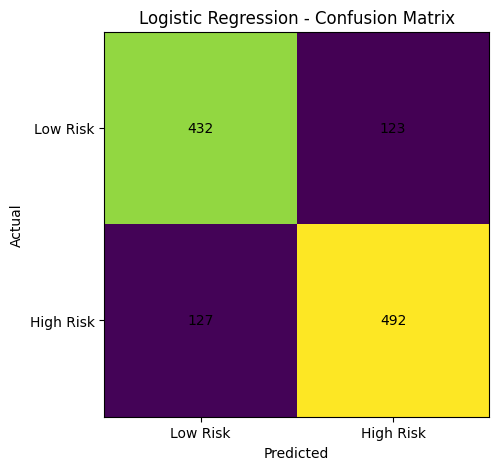

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predictions from Logistic Regression
y_pred = logistic_model.predict(X_test)

# Classification report
print("Logistic Regression Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Low Risk", "High Risk"]
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Low Risk", "High Risk"])
plt.yticks([0, 1], ["Low Risk", "High Risk"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [25]:
import joblib
import os

# Create model folder
os.makedirs("model", exist_ok=True)

# Save the complete trained pipeline
joblib.dump(
    logistic_model,
    "model/masld_logistic_model.pkl"
)

print("Model saved successfully.")
print("File: model/masld_logistic_model.pkl")

Model saved successfully.
File: model/masld_logistic_model.pkl


In [26]:
# Save the feature order used by the model

print("Feature order:")
for i, feature in enumerate(feature_cols, start=1):
    print(f"{i}. {feature}")

Feature order:
1. Age
2. Sex
3. BMI
4. Waist
5. Systolic_BP
6. Diastolic_BP
7. Glucose
8. HDL
9. Total_Cholesterol
10. Triglycerides
11. Sedentary_Minutes
12. Alcohol_Ever
